<a href="https://colab.research.google.com/github/Amri1003/Deep_Learning_Projects/blob/main/UsingANN_LendingClubLoanDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries imported')

All library imported


In [ ]:
# load the data
data=pd.read_csv('loan_data.csv')

In [ ]:
data.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [ ]:
data['not.fully.paid'].value_counts()

,count
not.fully.paid,
0,8045
1,1533


#EDA

<Axes: xlabel='not.fully.paid'>

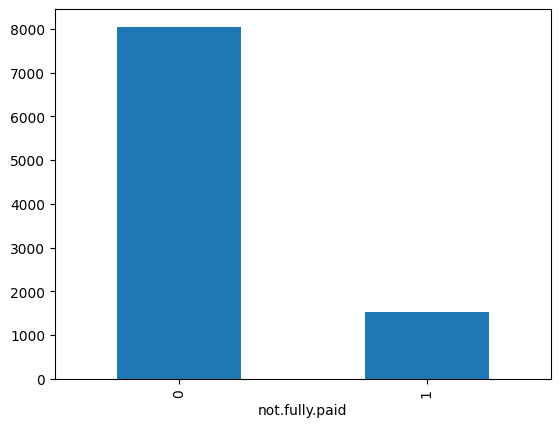

In [ ]:
data['not.fully.paid'].value_counts().plot(kind='bar')

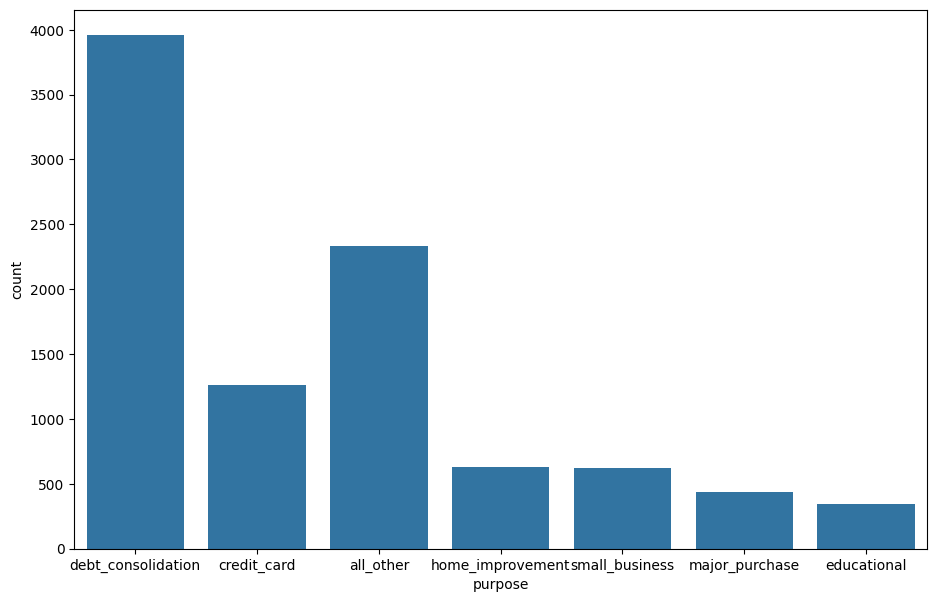

In [ ]:
# purpose
plt.figure(figsize=(11,7))
sns.countplot(x=data['purpose'])
plt.show()

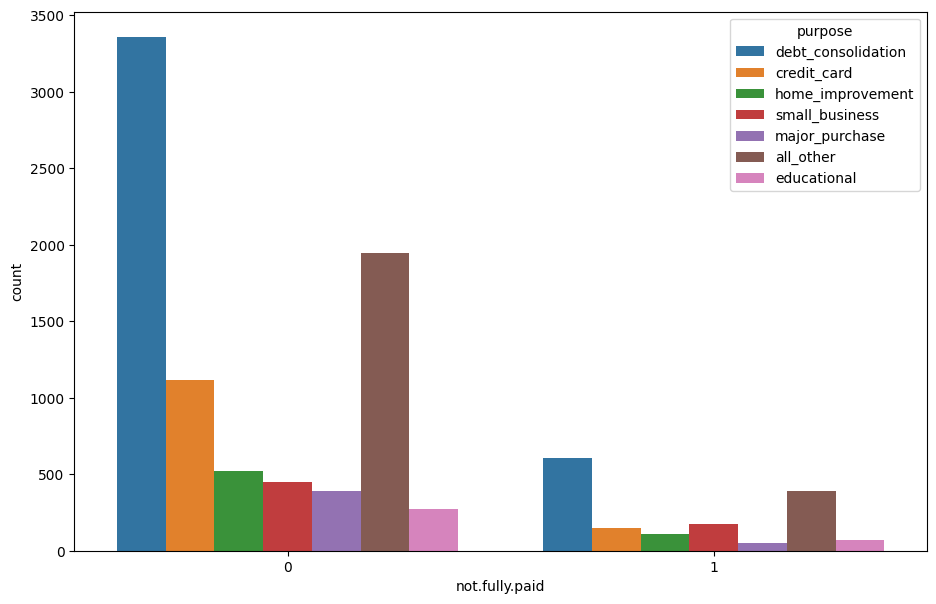

In [ ]:
# EDA
plt.figure(figsize=(11,7))
sns.countplot(x='not.fully.paid',hue='purpose',data=data)
plt.show()


# Data Preprocessing

In [ ]:
#Handle Imbalance data
not_fully_paid_0=data[data['not.fully.paid']==0]
not_fully_paid_1=data[data['not.fully.paid']==1]

In [ ]:
not_fully_paid_0.shape

(8045, 14)

In [ ]:
not_fully_paid_1.shape

(1533, 14)

In [ ]:
# resample
from sklearn.utils import resample
minor_upsample=resample(not_fully_paid_1,replace=True,n_samples=8045)
new_df=pd.concat([not_fully_paid_0,minor_upsample])

#shuffle
from sklearn.utils import shuffle
new_df=shuffle(new_df)

In [ ]:
new_df['not.fully.paid'].value_counts()

,count
not.fully.paid,
0,8045
1,8045


In [ ]:
new_df.shape

(16090, 14)

# Transform categorical values into numerical values (discrete)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [ ]:
# Apply labelencoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
for i in new_df.columns:
  if new_df[i].dtypes=='object':
    new_df[i]=le.fit_transform(new_df[i])

In [ ]:
new_df['purpose']

,purpose
960,2
3446,2
3983,0
3639,3
5231,0
...,...
419,1
1966,2
6738,2
3547,2


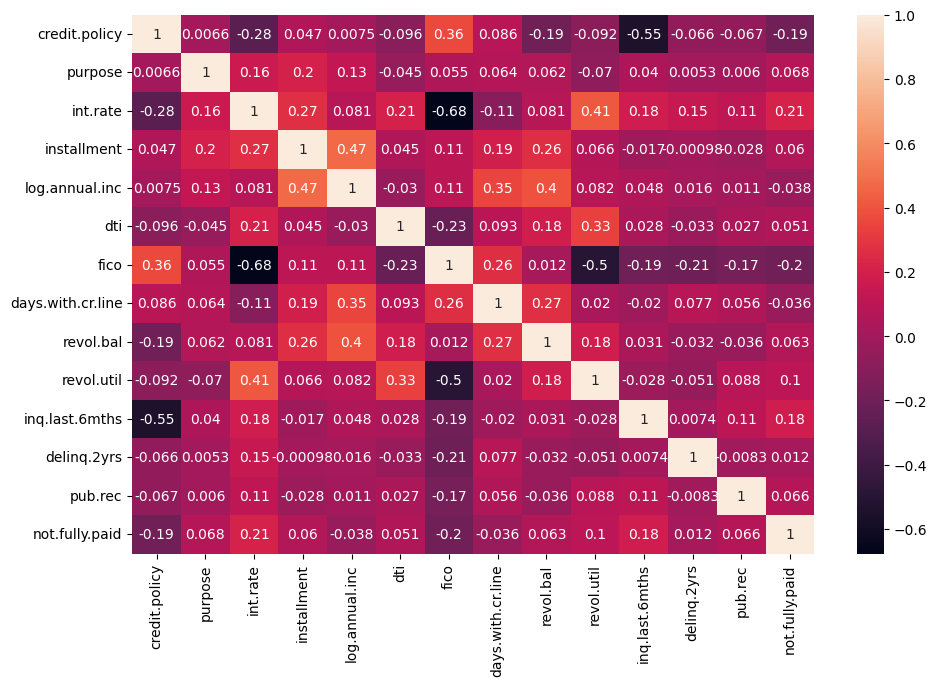

In [ ]:
plt.figure(figsize=(11,7))
sns.heatmap(new_df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
new_df.corr().abs()['not.fully.paid'].sort_values(ascending=False)

,not.fully.paid
not.fully.paid,1.000000
int.rate,0.212213
fico,0.198239
credit.policy,0.193359
inq.last.6mths,0.176444
revol.util,0.101367
purpose,0.067868
pub.rec,0.065739
revol.bal,0.062821
installment,0.060001


In [ ]:
X=new_df[['credit.policy', 'purpose', 'int.rate', 'installment',
       'fico', 'revol.bal', 'revol.util',
       'inq.last.6mths','pub.rec',]]

In [ ]:
y=new_df[['not.fully.paid']]

# Build ANN

In [ ]:
# Create Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# apply standard scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
# import library
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
print('All library imported')

All library imported


In [ ]:
# Create Architecture
model=Sequential()
# first Hidden Layer
model.add(Dense(19,activation='relu',input_shape=(9,)))
model.add(Dropout(0.2))
model.add(BatchNormalization())
# second Hidden Layer
model.add(Dense(10,activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
# third Hidden Layer
model.add(Dense(10,activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

# output layer
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 19)             │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19)             │            76 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667 (2.61 KB)

 Trainable params: 589 (2.30 KB)

 Non-trainable params: 78 (312.00 B)

In [ ]:
# compile the model
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print('model is compiled')

model is compiled


In [ ]:
# Run the model
history=model.fit(X_train,y_train,
                  epochs=50,
                  batch_size=256,
                  validation_data=(X_test,y_test),
                  )

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5317 - loss: 0.7733 - val_accuracy: 0.5845 - val_loss: 0.6649
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5569 - loss: 0.7199 - val_accuracy: 0.6066 - val_loss: 0.6575
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5672 - loss: 0.6973 - val_accuracy: 0.6106 - val_loss: 0.6548
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5713 - loss: 0.6889 - val_accuracy: 0.6255 - val_loss: 0.6526
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5752 - loss: 0.6842 - val_accuracy: 0.6190 - val_loss: 0.6513
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5770 - loss: 0.6749 - val_accuracy: 0.6262 - val_loss: 0.6496
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5862 - loss: 0.6700 - val_accuracy: 0.6290 - val_loss: 0.6481
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5806 - loss: 0.6723 - val_accuracy: 0.6293 - val_los

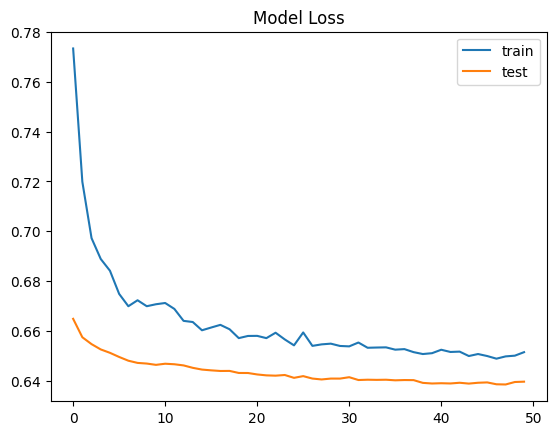

In [ ]:
# plot the losses
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['train','test'],loc='best')
plt.show()

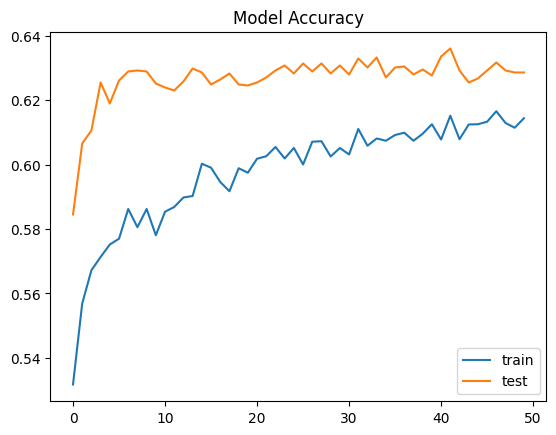

In [ ]:
# plot the Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['train','test'],loc='best')
plt.show()

In [ ]:
# Evaluate the model
# test accuracy
model.evaluate(X_test,y_test)

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6287 - loss: 0.6397


[0.6396957039833069, 0.6286513209342957]

In [ ]:
# train accuracy
model.evaluate(X_train,y_train)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6278 - loss: 0.6411


[0.6410596966743469, 0.6277967691421509]

In [ ]:
# prediction
pred=model.predict(X_test)
pred

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.4460241 ],
       [0.3428598 ],
       [0.49627545],
       ...,
       [0.759809  ],
       [0.46827972],
       [0.5060855 ]], dtype=float32)

In [ ]:
predict=(pred>0.5).astype('int')
predict

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [1]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.63      0.63      0.63      1612
           1       0.63      0.63      0.63      1606

    accuracy                           0.63      3218
   macro avg       0.63      0.63      0.63      3218
weighted avg       0.63      0.63      0.63      3218

